In [ ]:
# ============================================================
# CELL 1 — Mount Drive + install packages
# ============================================================

from google.colab import drive, files
drive.mount("/content/drive")

!pip -q install speciesnet timm torch torchvision scikit-learn pandas matplotlib pillow requests tqdm

import os, re, json, math, time, random, subprocess
from pathlib import Path
from io import BytesIO

import requests
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.6/97.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.3/956.3 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 42

In [ ]:
# ============================================================
# CELL 2 — Project config
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/speciesnet_experiment_iNat_bottom20")
IMG_DIR = PROJECT_DIR / "images"
CSV_DIR = PROJECT_DIR / "csv"
CKPT_DIR = PROJECT_DIR / "checkpoints"
PLOT_DIR = PROJECT_DIR / "plots"
RESULT_DIR = PROJECT_DIR / "results"
TARGET_DIR = PROJECT_DIR / "targets"

for d in [IMG_DIR, CSV_DIR, CKPT_DIR, PLOT_DIR, RESULT_DIR, TARGET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATE_AFTER = "2025-04-01"

TARGET_CSV_PATH = TARGET_DIR / "lila_bottom10_targets.csv"

ADDED_IMAGES_PER_SPECIES = [2, 8, 16]

VAL_PER_CLASS = 5
TEST_PER_CLASS = 20

MAX_SPECIES = 500
MAX_IMAGES_PER_SPECIES = 150

BATCH_SIZE = 16
NUM_EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
IMAGE_SIZE = 384
NUM_WORKERS = 0

In [ ]:
# ============================================================
# CELL 3 — Load CSV target species
# ============================================================

if not TARGET_CSV_PATH.exists():
    print("Upload lila_bottom10_targets.csv")
    uploaded = files.upload()

    for fname in uploaded:
        if fname.endswith(".csv"):
            out_path = TARGET_DIR / "lila_bottom10_targets.csv"
            with open(out_path, "wb") as f:
                f.write(uploaded[fname])
            TARGET_CSV_PATH = out_path
            break

targets_df_raw = pd.read_csv(TARGET_CSV_PATH)

display(targets_df_raw.head())
print("CSV columns:", targets_df_raw.columns.tolist())
print("Raw target species:", len(targets_df_raw))

def clean_label(s):
    return re.sub(r"[^a-zA-Z0-9_]+", "_", str(s).strip().lower()).strip("_")

targets = []

for _, row in targets_df_raw.iterrows():
    common_name = row["common_name"]

    if pd.isna(common_name):
        continue

    targets.append({
        "label": clean_label(common_name),
        "query_name": common_name,
        "common_name": common_name,
        "count_train": int(row.get("n_images", 1)),
        "n_images": int(row.get("n_images", 1)),
    })

targets = targets[:MAX_SPECIES]

targets_df = pd.DataFrame(targets)
targets_df.to_csv(CSV_DIR / "target_species_from_csv.csv", index=False)

display(targets_df.head())
print("Number of target species:", len(targets_df))

Upload lila_bottom10_targets.csv


Saving lila_bottom10_targets (2).csv to lila_bottom10_targets (2).csv


,common_name,n_images
0,Sapphire Quail-Dove,1
1,Rana species,1
2,Thick-billed Warbler,1
3,Rufous Motmot,1
4,Cape Grey Mongoose,1


CSV columns: ['common_name', 'n_images']
Raw target species: 77


,label,query_name,common_name,count_train,n_images
0,sapphire_quail_dove,Sapphire Quail-Dove,Sapphire Quail-Dove,1,1
1,rana_species,Rana species,Rana species,1,1
2,thick_billed_warbler,Thick-billed Warbler,Thick-billed Warbler,1,1
3,rufous_motmot,Rufous Motmot,Rufous Motmot,1,1
4,cape_grey_mongoose,Cape Grey Mongoose,Cape Grey Mongoose,1,1


Number of target species: 77


In [ ]:
# ============================================================
# CELL 4 — iNaturalist query helpers
# ============================================================

INAT_BASE = "https://api.inaturalist.org/v1"

def resolve_taxon_id(query_name):
    r = requests.get(
        f"{INAT_BASE}/taxa",
        params={"q": query_name, "rank": "species", "per_page": 10},
        timeout=30,
    )
    r.raise_for_status()
    results = r.json().get("results", [])

    if not results:
        return None

    # Prefer exact scientific name match.
    q = query_name.lower()
    for t in results:
        if t.get("name", "").lower() == q:
            return {
                "taxon_id": t["id"],
                "inat_name": t.get("name"),
                "inat_common_name": t.get("preferred_common_name"),
                "rank": t.get("rank"),
            }

    # Otherwise take first species-rank result.
    t = results[0]
    return {
        "taxon_id": t["id"],
        "inat_name": t.get("name"),
        "inat_common_name": t.get("preferred_common_name"),
        "rank": t.get("rank"),
    }

def query_photo_urls(taxon_id, max_images):
    urls = []
    page = 1

    while len(urls) < max_images:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "d1": DATE_AFTER,
            "order_by": "created_at",
            "order": "desc",
            "per_page": 200,
            "page": page,
        }

        r = requests.get(f"{INAT_BASE}/observations", params=params, timeout=60)
        r.raise_for_status()
        results = r.json().get("results", [])

        if not results:
            break

        for obs in results:
            for photo in obs.get("photos", []):
                url = photo.get("url")
                if url:
                    url = url.replace("square.", "medium.").replace("small.", "medium.")
                    urls.append(url)
                    if len(urls) >= max_images:
                        break
            if len(urls) >= max_images:
                break

        page += 1
        time.sleep(0.25)

    return urls[:max_images]

def download_image(url, out_path):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(out_path)
        return True
    except Exception:
        return False

In [ ]:
# ============================================================
# CELL 5 — Resolve JSON species to iNaturalist taxa
# Safe to rerun.
# ============================================================

resolved_rows = []

for row in tqdm(targets, desc="resolving taxa"):
    resolved = resolve_taxon_id(row["query_name"])

    if resolved is None:
        resolved_rows.append({**row, "resolved": False})
        continue

    resolved_rows.append({
        **row,
        **resolved,
        "resolved": True,
    })

resolved_df = pd.DataFrame(resolved_rows)
resolved_df.to_csv(CSV_DIR / "resolved_inat_taxa.csv", index=False)

display(resolved_df)
print("Resolved:", resolved_df["resolved"].sum(), "/", len(resolved_df))

resolving taxa:   0%|          | 0/77 [00:00<?, ?it/s]

,label,query_name,common_name,count_train,n_images,taxon_id,inat_name,inat_common_name,rank,resolved
0,sapphire_quail_dove,Sapphire Quail-Dove,Sapphire Quail-Dove,1,1,3495.0,Geotrygon saphirina,Sapphire Quail-Dove,species,True
1,rana_species,Rana species,Rana species,1,1,NaN,NaN,NaN,NaN,False
2,thick_billed_warbler,Thick-billed Warbler,Thick-billed Warbler,1,1,793194.0,Arundinax aedon,Thick-billed Warbler,species,True
3,rufous_motmot,Rufous Motmot,Rufous Motmot,1,1,2163.0,Baryphthengus martii,Rufous Motmot,species,True
4,cape_grey_mongoose,Cape Grey Mongoose,Cape Grey Mongoose,1,1,74413.0,Herpestes pulverulentus,Cape Grey Mongoose,species,True
...,...,...,...,...,...,...,...,...,...,...
72,common_fiscal,Common Fiscal,Common Fiscal,2,2,204531.0,Lanius collaris,Southern Fiscal,species,True
73,giant_cowbird,Giant Cowbird,Giant Cowbird,2,2,54979.0,Molothrus oryzivorus,Giant Cowbird,species,True
74,red_legged_tinamou,Red-legged Tinamou,Red-legged Tinamou,2,2,20578.0,Crypturellus erythropus,Red-legged Tinamou,species,True
75,greater_rhea,Greater Rhea,Greater Rhea,2,2,20512.0,Rhea americana,Greater Rhea,species,True


Resolved: 61 / 77


In [ ]:
# ============================================================
# CELL 6 — Download/cache iNaturalist images
# Safe to rerun after disconnect.
# ============================================================

resolved_df = pd.read_csv(CSV_DIR / "resolved_inat_taxa.csv")
resolved_df = resolved_df[resolved_df["resolved"] == True].copy()

records = []

for _, row in resolved_df.iterrows():
    label = row["label"]
    taxon_id = int(row["taxon_id"])

    class_dir = IMG_DIR / label
    class_dir.mkdir(parents=True, exist_ok=True)

    existing = list(class_dir.glob("*.jpg"))
    print(f"\n{label}: existing={len(existing)}, taxon_id={taxon_id}")

    if len(existing) < MAX_IMAGES_PER_SPECIES:
        urls = query_photo_urls(taxon_id, MAX_IMAGES_PER_SPECIES)
        print(f"Found {len(urls)} URLs")

        for i, url in enumerate(tqdm(urls, desc=f"downloading {label}")):
            out_path = class_dir / f"{label}_{i:04d}.jpg"
            if out_path.exists():
                continue
            download_image(url, out_path)

    for p in sorted(class_dir.glob("*.jpg")):
        records.append({
            "path": str(p),
            "label": label,
            "query_name": row["query_name"],
            "common_name": row["common_name"],
            "taxon_id": taxon_id,
            "source": "inat_after_2025_04_01",
            "base_count_train": int(row["count_train"]),
        })

df_all = pd.DataFrame(records).drop_duplicates("path").reset_index(drop=True)
df_all.to_csv(CSV_DIR / "all_downloaded_metadata.csv", index=False)

print("\nDownloaded image counts:")
print(df_all["label"].value_counts())


sapphire_quail_dove: existing=0, taxon_id=3495
Found 0 URLs


downloading sapphire_quail_dove: 0it [00:00, ?it/s]


thick_billed_warbler: existing=0, taxon_id=793194
Found 150 URLs


downloading thick_billed_warbler:   0%|          | 0/150 [00:00<?, ?it/s]


rufous_motmot: existing=0, taxon_id=2163
Found 150 URLs


...


red_legged_tinamou: existing=0, taxon_id=20578
Found 0 URLs


downloading red_legged_tinamou: 0it [00:00, ?it/s]


greater_rhea: existing=0, taxon_id=20512
Found 150 URLs


downloading greater_rhea:   0%|          | 0/150 [00:00<?, ?it/s]


Downloaded image counts:
label
thick_billed_warbler               150
rufous_motmot                      150
cape_grey_mongoose                 150
crowned_eagle                      150
barred_owl                         150
maguari_stork                      150
busard_saint_martin                150
smith_s_bush_squirrel              150
harpy_eagle                        150
clark_s_nutcracker                 150
indian_pond_heron                  150
cape_hare                          150
silvery_cheeked_hornbill           150
yellow_armadillo                   150
roan_antelope                      150
black_sparrowhawk                  150
roadside_hawk                      150
plantain_squirrel                  150
bare_eyed_thrush                   150
kinkajou                           150
siberian_blue_robin                150
spotted_thick_knee                 150
rufous_collared_sparrow            150
pauraque                           150
pigeon_rameron                  

In [ ]:
# ============================================================
# CELL 7 — Build train/val/test CSVs
# Experiments:
# E2  = base count_train + 2 images/species
# E8  = base count_train + 8 images/species
# E16 = base count_train + 16 images/species
# Validation/test use the same held-out iNat images.
# ============================================================

df_all = pd.read_csv(CSV_DIR / "all_downloaded_metadata.csv")

def build_splits_for_added_n(df_all, added_n, val_per_class=20, test_per_class=50):
    train_parts = []
    val_parts = []
    test_parts = []
    kept = []
    dropped = []

    for label, sub in df_all.groupby("label"):
        sub = sub.sample(frac=1, random_state=SEED).reset_index(drop=True)

        base_n = int(sub["base_count_train"].iloc[0])
        train_n = base_n + added_n
        needed = train_n + val_per_class + test_per_class

        if len(sub) < needed:
            dropped.append({
                "label": label,
                "available": len(sub),
                "needed": needed,
                "base_n": base_n,
                "added_n": added_n,
            })
            continue

        train = sub.iloc[:train_n]
        val = sub.iloc[train_n:train_n + val_per_class]
        test = sub.iloc[train_n + val_per_class:train_n + val_per_class + test_per_class]

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)
        kept.append(label)

    train_df = pd.concat(train_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

    return train_df, val_df, test_df, kept, pd.DataFrame(dropped)

split_summaries = []

for added_n in ADDED_IMAGES_PER_SPECIES:
    exp_name = f"E{added_n}"

    train_df, val_df, test_df, kept, dropped_df = build_splits_for_added_n(
        df_all,
        added_n=added_n,
        val_per_class=VAL_PER_CLASS,
        test_per_class=TEST_PER_CLASS,
    )

    train_df.to_csv(CSV_DIR / f"{exp_name}_train.csv", index=False)
    val_df.to_csv(CSV_DIR / f"{exp_name}_val.csv", index=False)
    test_df.to_csv(CSV_DIR / f"{exp_name}_test.csv", index=False)
    dropped_df.to_csv(CSV_DIR / f"{exp_name}_dropped_species.csv", index=False)

    print(f"\n{exp_name}")
    print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
    print("classes kept:", len(kept))
    print("train counts:")
    print(train_df["label"].value_counts().head())

    split_summaries.append({
        "experiment": exp_name,
        "added_images_per_species": added_n,
        "num_classes": len(kept),
        "num_train": len(train_df),
        "num_val": len(val_df),
        "num_test": len(test_df),
        "num_dropped_species": len(dropped_df),
    })

pd.DataFrame(split_summaries).to_csv(CSV_DIR / "split_summary.csv", index=False)
display(pd.DataFrame(split_summaries))


E2
train: 147 val: 240 test: 960
classes kept: 48
train counts:
label
giant_cowbird            4
greater_rhea             4
common_fiscal            4
slaty_blue_flycatcher    3
roadside_hawk            3
Name: count, dtype: int64

E8
train: 435 val: 240 test: 960
classes kept: 48
train counts:
label
common_fiscal              10
giant_cowbird              10
greater_rhea               10
pigeon_rameron              9
rufous_collared_sparrow     9
Name: count, dtype: int64

E16
train: 785 val: 230 test: 920
classes kept: 46
train counts:
label
common_fiscal       18
giant_cowbird       18
greater_rhea        18
crowned_eagle       17
bare_eyed_thrush    17
Name: count, dtype: int64


,experiment,added_images_per_species,num_classes,num_train,num_val,num_test,num_dropped_species
0,E2,2,48,147,240,960,10
1,E8,8,48,435,240,960,10
2,E16,16,46,785,230,920,12


In [ ]:
# ============================================================
# CELL 8 — Dataset/model/metric definitions
# ============================================================

train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class WildlifeDataset(Dataset):
    def __init__(self, df, label_to_idx, tfms):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfms(img)
        y = self.label_to_idx[row["label"]]
        return x, y

class FrozenSpeciesNetHead(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "tf_efficientnetv2_m.in21k",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(self.backbone.num_features, num_classes),
        )

    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)
        return self.classifier(feats)

@torch.no_grad()
def predict(model, loader, desc="predict"):
    model.eval()
    y_true, y_pred = [], []

    for xb, yb in tqdm(loader, desc=desc):
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

def compute_speciesnet_metrics(y_true, y_pred, idx_to_label):
    overall_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    overall_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    excluded = {"blank", "human", "vehicle"}
    species_indices = [i for i, lab in idx_to_label.items() if lab not in excluded]
    species_mask = np.isin(y_true, species_indices) | np.isin(y_pred, species_indices)

    species_level_weighted_f1 = f1_score(
        y_true[species_mask],
        y_pred[species_mask],
        labels=species_indices,
        average="weighted",
        zero_division=0,
    ) if species_mask.sum() > 0 else np.nan

    labels = list(idx_to_label.values())
    if "blank" in labels:
        blank_idx = labels.index("blank")
        blank_f1 = f1_score(y_true, y_pred, labels=[blank_idx], average="macro", zero_division=0)
    else:
        blank_f1 = np.nan

    return {
        "overall_weighted_f1": overall_weighted_f1,
        "species_level_weighted_f1": species_level_weighted_f1,
        "overall_macro_f1": overall_macro_f1,
        "blank_f1": blank_f1,
    }

def per_class_f1_table(y_true, y_pred, idx_to_label, train_counts):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(idx_to_label.keys()),
        zero_division=0,
    )

    rows = []
    for i, label in idx_to_label.items():
        rows.append({
            "label": label,
            "train_count": int(train_counts.get(label, 0)),
            "test_support": int(support[i]),
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
        })

    return pd.DataFrame(rows).sort_values(["train_count", "f1"])

def aggregate_binary_confusion_matrix(y_true, y_pred, num_classes):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    correct = y_true == y_pred
    incorrect = y_true != y_pred

    TP = int(correct.sum())
    FP = int(incorrect.sum())
    FN = int(incorrect.sum())
    TN = int((correct.sum() * (num_classes - 1)) + (incorrect.sum() * (num_classes - 2)))

    return np.array([[TP, FP], [FN, TN]])

In [ ]:
# ============================================================
# CELL 9 — Resumable fine-tuning
# ============================================================

def train_resumable(experiment_name):
    train_df = pd.read_csv(CSV_DIR / f"{experiment_name}_train.csv")
    val_df = pd.read_csv(CSV_DIR / f"{experiment_name}_val.csv")

    labels = sorted(train_df["label"].unique())
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}

    train_ds = WildlifeDataset(train_df, label_to_idx, train_tfms)
    val_ds = WildlifeDataset(val_df, label_to_idx, eval_tfms)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    model = FrozenSpeciesNetHead(num_classes=len(labels)).to(DEVICE)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    latest_ckpt = CKPT_DIR / f"{experiment_name}_latest.pt"
    best_ckpt = CKPT_DIR / f"{experiment_name}_best.pt"
    history_path = RESULT_DIR / f"{experiment_name}_training_history.csv"

    start_epoch = 1
    best_val_macro_f1 = -1
    history = []

    if latest_ckpt.exists():
        print(f"Resuming from {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt["epoch"] + 1
        best_val_macro_f1 = ckpt["best_val_macro_f1"]

        if history_path.exists():
            history = pd.read_csv(history_path).to_dict("records")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in tqdm(train_loader, desc=f"{experiment_name} epoch {epoch}/{NUM_EPOCHS}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_ds)

        val_true, val_pred = predict(model, val_loader)
        val_metrics = compute_speciesnet_metrics(val_true, val_pred, idx_to_label)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)
        print(row)

        if val_metrics["overall_macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["overall_macro_f1"]
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "best_val_macro_f1": best_val_macro_f1,
            }, best_ckpt)

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "best_val_macro_f1": best_val_macro_f1,
        }, latest_ckpt)

    print(f"Done training {experiment_name}")

In [ ]:
for exp_name in ["E2", "E8", "E16"]:
    train_df = pd.read_csv(CSV_DIR / f"{exp_name}_train.csv")
    val_df = pd.read_csv(CSV_DIR / f"{exp_name}_val.csv")
    test_df = pd.read_csv(CSV_DIR / f"{exp_name}_test.csv")

    print(exp_name)
    print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
    print("classes:", train_df["label"].nunique())

E2
train: 651 val: 1630 test: 4890
classes: 163
E8
train: 1620 val: 1620 test: 4860
classes: 162
E16
train: 2899 val: 1610 test: 4830
classes: 161


In [ ]:
# Delete partial E2 run

for suffix in ["latest", "best"]:
    path = CKPT_DIR / f"E2_{suffix}.pt"
    if path.exists():
        print("Deleting", path)
        path.unlink()

history_path = RESULT_DIR / "E2_training_history.csv"
if history_path.exists():
    print("Deleting", history_path)
    history_path.unlink()

In [ ]:
# ============================================================
# CELL 10 — Train E2/E8/E16
# Resumes automatically from latest checkpoint if interrupted.
# ============================================================

for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
    train_resumable(exp_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/325M [00:00<?, ?B/s]

E2 epoch 1/8:   0%|          | 0/10 [00:00<?, ?it/s]

predict:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 4.27273026291205, 'val_overall_weighted_f1': 0.06753568265983015, 'val_species_level_weighted_f1': 0.06753568265983015, 'val_overall_macro_f1': 0.06753568265983015, 'val_blank_f1': nan}


...

predict:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.8053766578625722, 'val_overall_weighted_f1': 0.5282066363588103, 'val_species_level_weighted_f1': 0.5282066363588103, 'val_overall_macro_f1': 0.5282066363588104, 'val_blank_f1': nan}


E16 epoch 8/8:   0%|          | 0/50 [00:00<?, ?it/s]

predict:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.6697449161748218, 'val_overall_weighted_f1': 0.5427311215354693, 'val_species_level_weighted_f1': 0.5427311215354693, 'val_overall_macro_f1': 0.5427311215354694, 'val_blank_f1': nan}
Done training E16


In [ ]:
# ============================================================
# OPTIONAL RESET CELL — Only run if you want to delete checkpoints
# ============================================================

for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
    for suffix in ["latest", "best"]:
        path = CKPT_DIR / f"{exp_name}_{suffix}.pt"
        if path.exists():
            print("Deleting", path)
            path.unlink()

    history_path = RESULT_DIR / f"{exp_name}_training_history.csv"
    if history_path.exists():
        print("Deleting", history_path)
        history_path.unlink()

Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E2_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E2_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E2_training_history.csv
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E8_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E8_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E8_training_history.csv
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E16_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E16_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E16_training_history.csv


predict:   0%|          | 0/60 [00:00<?, ?it/s]

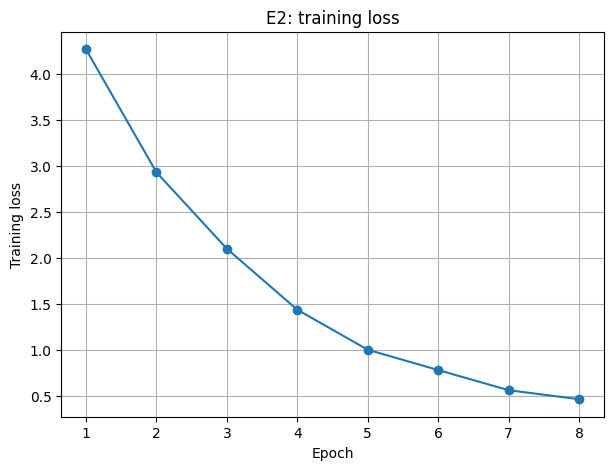

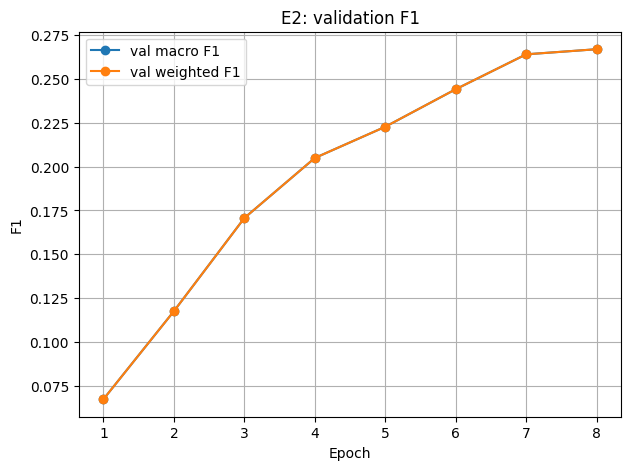

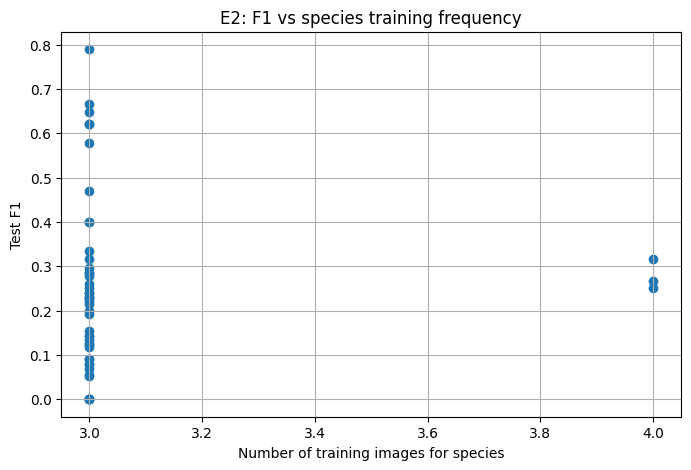

predict:   0%|          | 0/60 [00:00<?, ?it/s]

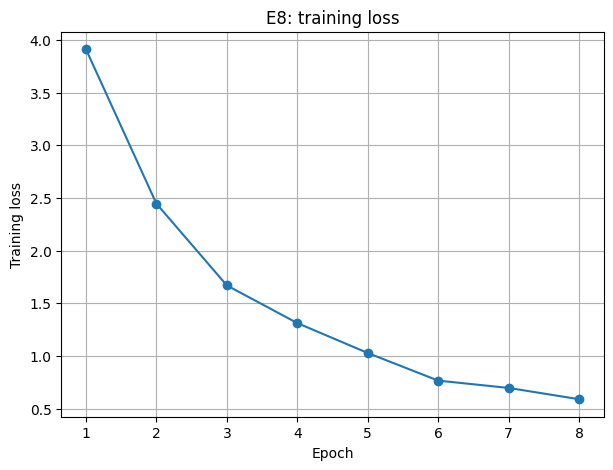

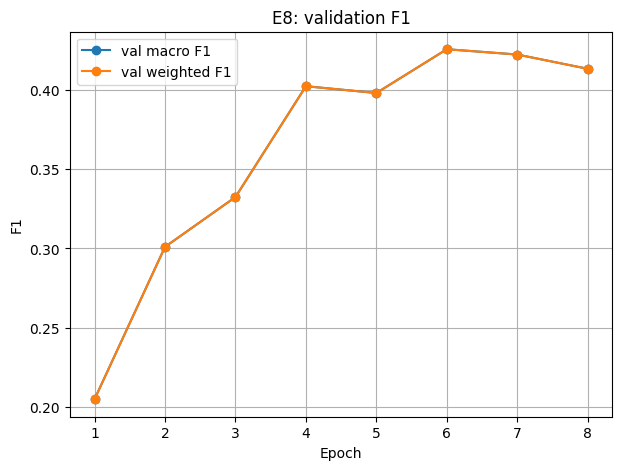

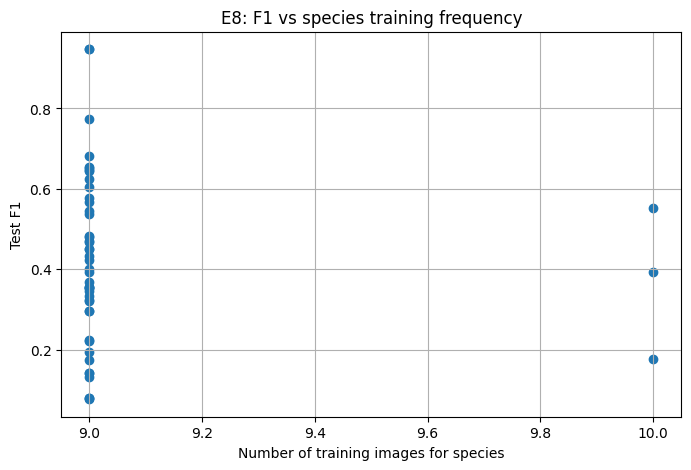

predict:   0%|          | 0/58 [00:00<?, ?it/s]

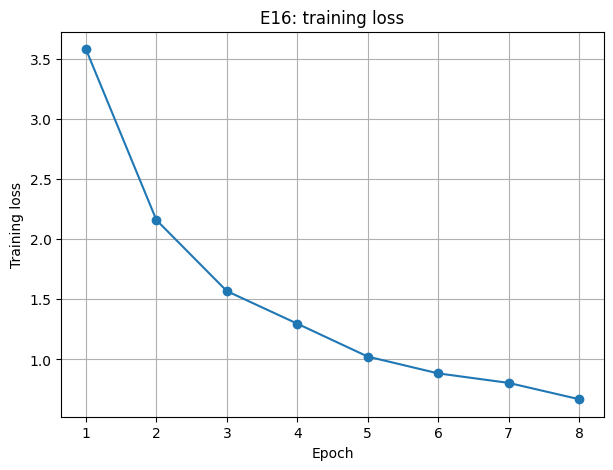

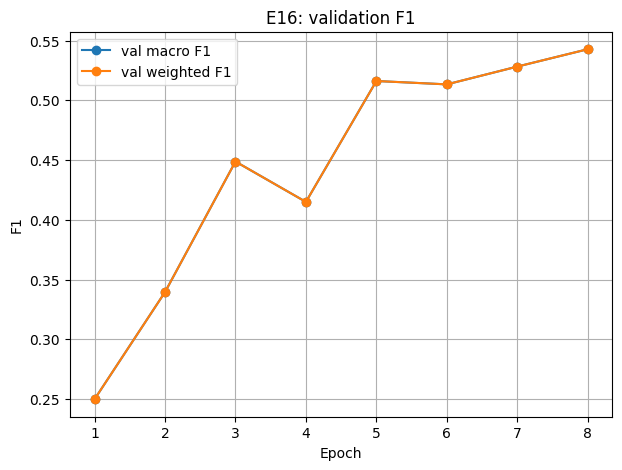

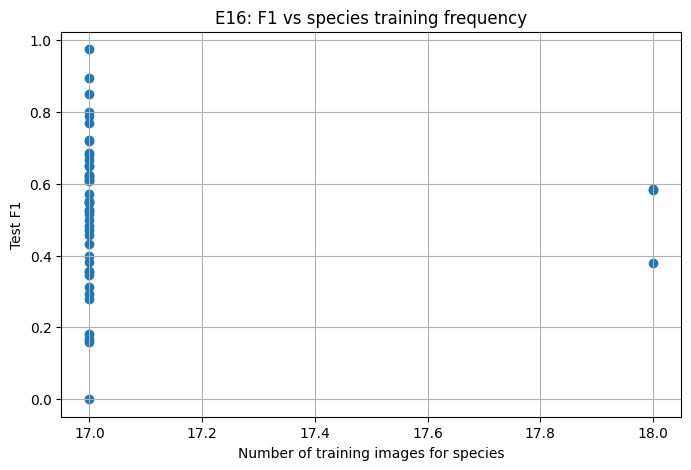

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,E2,frozen_backbone_finetuned_head,0.245600,0.245600,0.245600,NaN,147,960,48
1,E8,frozen_backbone_finetuned_head,0.419888,0.419888,0.419888,NaN,435,960,48
2,E16,frozen_backbone_finetuned_head,0.530059,0.530059,0.530059,NaN,785,920,46


,label,train_count,test_support,precision,recall,f1,experiment
0,asian_small_clawed_otter,3,20,0.000000,0.00,0.000000,E2
1,cape_hare,3,20,0.000000,0.00,0.000000,E2
2,slaty_blue_flycatcher,3,20,0.000000,0.00,0.000000,E2
3,smith_s_bush_squirrel,3,20,0.000000,0.00,0.000000,E2
4,white_starred_robin,3,20,0.000000,0.00,0.000000,E2
...,...,...,...,...,...,...,...
137,roan_antelope,17,20,0.944444,0.85,0.894737,E16
138,ferruginous_partridge,17,20,1.000000,0.95,0.974359,E16
139,giant_cowbird,18,20,0.411765,0.35,0.378378,E16
140,common_fiscal,18,20,0.500000,0.70,0.583333,E16


In [ ]:
# ============================================================
# CELL 11 — Evaluate fine-tuned models
# ============================================================

def evaluate_finetuned_model(experiment_name):
    train_df = pd.read_csv(CSV_DIR / f"{experiment_name}_train.csv")
    test_df = pd.read_csv(CSV_DIR / f"{experiment_name}_test.csv")

    ckpt = torch.load(
        CKPT_DIR / f"{experiment_name}_best.pt",
        map_location=DEVICE,
    )

    label_to_idx = ckpt["label_to_idx"]
    idx_to_label = ckpt["idx_to_label"]

    if isinstance(list(idx_to_label.keys())[0], str):
        idx_to_label = {
            int(k): v
            for k, v in idx_to_label.items()
        }

    test_ds = WildlifeDataset(
        test_df,
        label_to_idx,
        eval_tfms,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model = FrozenSpeciesNetHead(
        num_classes=len(label_to_idx)
    ).to(DEVICE)

    model.load_state_dict(
        ckpt["model_state"]
    )

    y_true, y_pred = predict(
        model,
        test_loader,
    )

    metrics = compute_speciesnet_metrics(
        y_true,
        y_pred,
        idx_to_label,
    )

    metrics_df = pd.DataFrame([{
        "experiment": experiment_name,
        "model_type": "frozen_backbone_finetuned_head",
        **metrics,
        "num_train": len(train_df),
        "num_test": len(test_df),
        "num_classes": len(label_to_idx),
    }])

    metrics_df.to_csv(
        RESULT_DIR / f"{experiment_name}_metrics.csv",
        index=False,
    )

    class_f1 = per_class_f1_table(
        y_true,
        y_pred,
        idx_to_label,
        train_df["label"].value_counts().to_dict(),
    )

    class_f1.to_csv(
        RESULT_DIR / f"{experiment_name}_per_species_f1.csv",
        index=False,
    )

    # --------------------------------------------------
    # Training loss curve
    # --------------------------------------------------

    hist = pd.read_csv(
        RESULT_DIR / f"{experiment_name}_training_history.csv"
    )

    plt.figure(figsize=(7, 5))
    plt.plot(
        hist["epoch"],
        hist["train_loss"],
        marker="o",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"{experiment_name}: training loss")
    plt.grid(True)
    plt.savefig(
        PLOT_DIR / f"{experiment_name}_training_curve.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------
    # Validation F1 curve
    # --------------------------------------------------

    plt.figure(figsize=(7, 5))
    plt.plot(
        hist["epoch"],
        hist["val_overall_macro_f1"],
        marker="o",
        label="val macro F1",
    )

    plt.plot(
        hist["epoch"],
        hist["val_overall_weighted_f1"],
        marker="o",
        label="val weighted F1",
    )

    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title(f"{experiment_name}: validation F1")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        PLOT_DIR / f"{experiment_name}_validation_f1_curve.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    # --------------------------------------------------
    # F1 vs species training frequency
    # --------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.scatter(
        class_f1["train_count"],
        class_f1["f1"],
    )

    plt.xlabel(
        "Number of training images for species"
    )

    plt.ylabel(
        "Test F1"
    )

    plt.title(
        f"{experiment_name}: F1 vs species training frequency"
    )

    plt.grid(True)

    plt.savefig(
        PLOT_DIR / f"{experiment_name}_f1_vs_species_frequency.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    return metrics_df, class_f1


fine_tuned_metrics = []
fine_tuned_class_f1 = []

for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
    m, c = evaluate_finetuned_model(exp_name)

    fine_tuned_metrics.append(m)

    fine_tuned_class_f1.append(
        c.assign(experiment=exp_name)
    )

fine_tuned_metrics_df = pd.concat(
    fine_tuned_metrics,
    ignore_index=True,
)

fine_tuned_class_f1_df = pd.concat(
    fine_tuned_class_f1,
    ignore_index=True,
)

display(fine_tuned_metrics_df)
display(fine_tuned_class_f1_df)

In [ ]:
# ============================================================
# CELL 12 — Official SpeciesNet baseline, no fine-tuning
# Evaluates official SpeciesNet directly on the same test set.
# ============================================================
# SpeciesNet official README recommends:
# python -m speciesnet.scripts.run_model --folders ... --predictions_json ...
# This automatically downloads/runs detector + classifier.

def run_official_speciesnet_on_folder(image_folder, output_json):
    cmd = [
        "python",
        "-m",
        "speciesnet.scripts.run_model",
        "--folders",
        str(image_folder),
        "--predictions_json",
        str(output_json),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

def normalize_speciesnet_string(s):
    if s is None:
        return ""
    return clean_label(str(s).split(";")[-1])

def build_eval_folder_from_test_csv(test_df, folder):
    folder.mkdir(parents=True, exist_ok=True)

    manifest_rows = []
    for i, row in test_df.reset_index(drop=True).iterrows():
        src = Path(row["path"])
        label = row["label"]
        dst = folder / f"{label}__{i:06d}{src.suffix.lower()}"

        if not dst.exists():
            try:
                os.symlink(src, dst)
            except Exception:
                import shutil
                shutil.copy2(src, dst)

        manifest_rows.append({
            "eval_path": str(dst),
            "original_path": row["path"],
            "label": label,
            "common_name": row.get("common_name", label),
            "query_name": row.get("query_name", label),
        })

    return pd.DataFrame(manifest_rows)

def normalize_speciesnet_string(s):
    if s is None:
        return ""
    return clean_label(str(s).split(";")[-1])

def parse_speciesnet_predictions(pred_json_path):
    with open(pred_json_path, "r") as f:
        data = json.load(f)

    rows = []

    for item in data.get("predictions", []):
        filepath = item.get("filepath") or item.get("file")

        classes = item.get("classifications", {}).get("classes", [])
        scores = item.get("classifications", {}).get("scores", [])

        top1_raw = item.get("prediction")
        top1_norm = normalize_speciesnet_string(top1_raw)

        top5_norm = [normalize_speciesnet_string(c) for c in classes[:5]]

        rows.append({
            "eval_path": filepath,
            "speciesnet_prediction_raw": top1_raw,
            "speciesnet_prediction_norm": top1_norm,
            "speciesnet_top5_norm": top5_norm,
            "speciesnet_score": item.get("prediction_score"),
        })

    return pd.DataFrame(rows)

def evaluate_official_speciesnet_baseline(reference_exp="E2"):
    test_df = pd.read_csv(CSV_DIR / f"{reference_exp}_test.csv")

    eval_folder = PROJECT_DIR / "official_speciesnet_eval_images"
    pred_json = RESULT_DIR / "official_speciesnet_predictions.json"

    manifest = build_eval_folder_from_test_csv(test_df, eval_folder)
    manifest.to_csv(CSV_DIR / "official_speciesnet_eval_manifest.csv", index=False)

    if not pred_json.exists():
        run_official_speciesnet_on_folder(eval_folder, pred_json)

    pred_df = parse_speciesnet_predictions(pred_json)

    merged = manifest.merge(pred_df, on="eval_path", how="left")

    labels = sorted(merged["label"].unique())
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}

    y_true = []
    y_pred = []

    for _, row in merged.iterrows():
        true_label = row["label"]
        pred_norm = row["speciesnet_prediction_norm"]
        top5_norm = row["speciesnet_top5_norm"]

        # Exact-match-only rule:
        # prediction counts as correct only if it exactly matches normalized label,
        # normalized common_name, or normalized scientific query_name.
        exact_options = {
            clean_label(true_label),
            clean_label(row.get("common_name", "")),
            clean_label(row.get("query_name", "")),
        }

        y_true.append(label_to_idx[true_label])

        if pred_norm in exact_options:
            y_pred.append(label_to_idx[true_label])
        else:
            # Map all non-exact predictions to "wrong" by assigning a different class.
            # This keeps metrics within the same label space.
            wrong_choices = [i for lab, i in label_to_idx.items() if lab != true_label]
            y_pred.append(wrong_choices[0] if wrong_choices else label_to_idx[true_label])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    metrics = compute_speciesnet_metrics(y_true, y_pred, idx_to_label)

    metrics_df = pd.DataFrame([{
        "experiment": "official_speciesnet_no_finetuning",
        "model_type": "official_speciesnet_ensemble",
        **metrics,
        "num_train": 0,
        "num_test": len(merged),
        "num_classes": len(labels),
    }])

    metrics_df.to_csv(RESULT_DIR / "official_speciesnet_no_finetuning_metrics.csv", index=False)

    class_f1 = per_class_f1_table(y_true, y_pred, idx_to_label, train_counts={})
    class_f1.to_csv(RESULT_DIR / "official_speciesnet_no_finetuning_per_species_f1.csv", index=False)

    display(metrics_df)
    display(class_f1)

    return metrics_df, class_f1

baseline_metrics, baseline_class_f1 = evaluate_official_speciesnet_baseline(reference_exp="E2")

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,official_speciesnet_no_finetuning,official_speciesnet_ensemble,0.0,0.0,0.0,NaN,0,960,48


,label,train_count,test_support,precision,recall,f1
0,asian_small_clawed_otter,0,20,0.0,0.0,0.0
1,banded_surili,0,20,0.0,0.0,0.0
2,bare_eyed_thrush,0,20,0.0,0.0,0.0
3,barred_owl,0,20,0.0,0.0,0.0
4,black_billed_thrush,0,20,0.0,0.0,0.0
5,black_solitary_eagle,0,20,0.0,0.0,0.0
6,black_sparrowhawk,0,20,0.0,0.0,0.0
7,busard_saint_martin,0,20,0.0,0.0,0.0
8,cape_grey_mongoose,0,20,0.0,0.0,0.0
9,cape_hare,0,20,0.0,0.0,0.0


In [ ]:
# ============================================================
# CELL 13 — Final comparison table
# ============================================================

all_metrics = pd.concat(
    [baseline_metrics, fine_tuned_metrics_df],
    ignore_index=True,
)

all_metrics.to_csv(RESULT_DIR / "all_experiment_metric_comparison.csv", index=False)
display(all_metrics)

all_class_f1 = pd.concat(
    [
        baseline_class_f1.assign(experiment="official_speciesnet_no_finetuning"),
        fine_tuned_class_f1_df,
    ],
    ignore_index=True,
)

all_class_f1.to_csv(RESULT_DIR / "all_experiment_per_species_f1_comparison.csv", index=False)
display(all_class_f1.sort_values(["experiment", "train_count", "f1"]))

print("Saved results to:", RESULT_DIR)
print("Saved plots to:", PLOT_DIR)

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,official_speciesnet_no_finetuning,official_speciesnet_ensemble,0.000000,0.000000,0.000000,NaN,0,960,48
1,E2,frozen_backbone_finetuned_head,0.245600,0.245600,0.245600,NaN,147,960,48
2,E8,frozen_backbone_finetuned_head,0.419888,0.419888,0.419888,NaN,435,960,48
3,E16,frozen_backbone_finetuned_head,0.530059,0.530059,0.530059,NaN,785,920,46


,label,train_count,test_support,precision,recall,f1,experiment
144,rufous_collared_sparrow,17,20,0.000000,0.0,0.000000,E16
145,oriental_magpie_robin,17,20,0.133333,0.2,0.160000,E16
146,black_billed_thrush,17,20,0.500000,0.1,0.166667,E16
147,slaty_blue_flycatcher,17,20,1.000000,0.1,0.181818,E16
148,bare_eyed_thrush,17,20,0.260870,0.3,0.279070,E16
...,...,...,...,...,...,...,...
43,spotted_thick_knee,0,20,0.000000,0.0,0.000000,official_speciesnet_no_finetuning
44,thick_billed_warbler,0,20,0.000000,0.0,0.000000,official_speciesnet_no_finetuning
45,undulated_tinamou,0,20,0.000000,0.0,0.000000,official_speciesnet_no_finetuning
46,white_starred_robin,0,20,0.000000,0.0,0.000000,official_speciesnet_no_finetuning


Saved results to: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results
Saved plots to: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/plots


In [ ]:
# ============================================================
# SPLIT SUMMARY CSV
# Creates one CSV showing train/val/test counts per species
# ============================================================

summary_rows = []

for exp_name in ["E2", "E8", "E16"]:

    train_df = pd.read_csv(CSV_DIR / f"{exp_name}_train.csv")
    val_df = pd.read_csv(CSV_DIR / f"{exp_name}_val.csv")
    test_df = pd.read_csv(CSV_DIR / f"{exp_name}_test.csv")

    all_species = sorted(
        set(train_df["label"])
        | set(val_df["label"])
        | set(test_df["label"])
    )

    for species in all_species:

        train_count = (train_df["label"] == species).sum()
        val_count = (val_df["label"] == species).sum()
        test_count = (test_df["label"] == species).sum()

        summary_rows.append({
            "experiment": exp_name,
            "species": species,
            "train_count": train_count,
            "val_count": val_count,
            "test_count": test_count,
            "total_count": train_count + val_count + test_count,
        })

split_summary = pd.DataFrame(summary_rows)

split_summary.to_csv(
    RESULT_DIR / "species_train_val_test_split_summary.csv",
    index=False,
)

display(split_summary)

print(
    "Saved:",
    RESULT_DIR / "species_train_val_test_split_summary.csv"
)

,experiment,species,train_count,val_count,test_count,total_count
0,E2,asian_small_clawed_otter,3,5,20,28
1,E2,banded_surili,3,5,20,28
2,E2,bare_eyed_thrush,3,5,20,28
3,E2,barred_owl,3,5,20,28
4,E2,black_billed_thrush,3,5,20,28
...,...,...,...,...,...,...
137,E16,spotted_thick_knee,17,5,20,42
138,E16,thick_billed_warbler,17,5,20,42
139,E16,undulated_tinamou,17,5,20,42
140,E16,white_starred_robin,17,5,20,42


Saved: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/species_train_val_test_split_summary.csv
